# Aula 5 — Exercício 4: Análise Arquitetural Aplicada (NUMA simulado em 1 socket)
### Versão **robusta para notebook** (sem `SharedMemory`)

Você estava batendo no erro `BufferError: cannot close exported pointers exist`, comum quando `multiprocessing.shared_memory` + `numpy.frombuffer` tentam fechar o `mmap` ainda com *views* ativas em notebooks.

**Para focar no objetivo didático (NUMA/afinidade/throughput), esta versão evita `SharedMemory`** e simula:
- 2 nós lógicos (A/B) via afinidade de CPU
- memória **local vs remota** via **penalidade artificial**
- migração de workers (quebra de localidade)

Isso mantém a análise arquitetural e elimina a instabilidade do `SharedMemory` em notebook.


In [1]:

# ✅ Setup
import os, sys, platform, subprocess
def sh(cmd):
    print("$", cmd)
    out = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    if out.stdout.strip(): print(out.stdout)
    if out.stderr.strip(): print(out.stderr)
    return out.returncode

print("Python:", sys.version)
print("Platform:", platform.platform())
sh("lscpu | egrep 'Model name|Socket|Core|Thread|CPU\\(s\\)|NUMA'")


Python: 3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
$ lscpu | egrep 'Model name|Socket|Core|Thread|CPU\(s\)|NUMA'
CPU(s):                               16
On-line CPU(s) list:                  0-15
Model name:                           12th Gen Intel(R) Core(TM) i7-12650H
Thread(s) per core:                   2
Core(s) per socket:                   8
Socket(s):                            1
NUMA node(s):                         1
NUMA node0 CPU(s):                    0-15



0

In [2]:

# ✅ 2 nós NUMA "lógicos" (emulação por afinidade)

from dataclasses import dataclass

def cpu_count():
    return os.cpu_count() or 1

@dataclass
class FakeNuma:
    nodeA: set
    nodeB: set

def make_fake_numa():
    n = cpu_count()
    half = max(1, n // 2)
    A = set(range(0, half))
    B = set(range(half, n)) or set(range(0, half))
    return FakeNuma(nodeA=A, nodeB=B)

fake = make_fake_numa()
print("CPUs totais:", cpu_count())
print("Node A:", sorted(fake.nodeA))
print("Node B:", sorted(fake.nodeB))


CPUs totais: 16
Node A: [0, 1, 2, 3, 4, 5, 6, 7]
Node B: [8, 9, 10, 11, 12, 13, 14, 15]


In [3]:

# ✅ Workload memory-bound (pouco FLOP por byte)

import numpy as np
import time

def memory_bound_step(arr_u8, block_size=1<<20):
    n = arr_u8.size
    acc = 0
    for i in range(0, n, block_size):
        acc += int(arr_u8[i:i+block_size].sum())
    return acc

def run_single(buf_mb=128, seconds=1.5):
    size = buf_mb * (1<<20)
    arr = np.ones(size, dtype=np.uint8)
    t0 = time.perf_counter()
    it = 0
    acc = 0
    while time.perf_counter() - t0 < seconds:
        acc ^= memory_bound_step(arr)
        it += 1
    dt = time.perf_counter() - t0
    return {"iters": it, "seconds": dt, "iters_per_s": it/dt, "acc": acc}

run_single()


{'iters': 30,
 'seconds': 1.5042259699999931,
 'iters_per_s': 19.943812032443596,
 'acc': 0}

In [4]:

# ✅ Multiprocessing robusto em notebook (WSL/Linux): usar "fork"

import multiprocessing as mp
import os, time
import numpy as np

def set_affinity(cpu_set):
    try:
        os.sched_setaffinity(0, cpu_set)
    except Exception:
        pass

def worker_loop(size, cpu_set, seconds, penalty_ns_per_mb, is_remote):
    set_affinity(cpu_set)
    # Cada worker aloca seu buffer (simula páginas locais do nó dele)
    arr = np.ones(size, dtype=np.uint8)

    t0 = time.perf_counter()
    it = 0
    acc = 0
    while time.perf_counter() - t0 < seconds:
        acc ^= memory_bound_step(arr)
        it += 1
        if is_remote and penalty_ns_per_mb > 0:
            mb = size / (1<<20)
            time.sleep((penalty_ns_per_mb * mb) / 1e9)
    return (it, acc)

def run_workers(n_workers=8, buf_mb=256, seconds=2.0,
                data_owner="A", penalty_ns_per_mb=0, migrate=False):
    fake = make_fake_numa()
    nodeA, nodeB = fake.nodeA, fake.nodeB

    size = buf_mb * (1<<20)

    # Distribui workers alternando A/B
    cpu_sets, my_nodes = [], []
    for i in range(n_workers):
        if i % 2 == 0:
            cpu_sets.append(nodeA); my_nodes.append("A")
        else:
            cpu_sets.append(nodeB); my_nodes.append("B")

    # WSL/Linux em notebook: fork é o mais estável
    ctx = mp.get_context("fork")
    pool = ctx.Pool(processes=n_workers)

    t0 = time.perf_counter()
    t_half = seconds/2 if migrate else seconds

    args = []
    for i in range(n_workers):
        is_remote = (my_nodes[i] != data_owner)
        args.append((size, cpu_sets[i], t_half, penalty_ns_per_mb, is_remote))
    out1 = pool.starmap(worker_loop, args)

    out2 = []
    if migrate:
        # troca A <-> B (simula migração)
        args2 = []
        for i in range(n_workers):
            new_node = "B" if my_nodes[i] == "A" else "A"
            new_cpu_set = nodeB if new_node == "B" else nodeA
            is_remote = (new_node != data_owner)
            args2.append((size, new_cpu_set, t_half, penalty_ns_per_mb, is_remote))
        out2 = pool.starmap(worker_loop, args2)

    pool.close(); pool.join()
    dt = time.perf_counter() - t0
    iters = sum(x[0] for x in out1) + sum(x[0] for x in out2)

    return {"workers": n_workers, "buf_mb": buf_mb, "seconds": dt,
            "iters_total": iters, "iters_per_s": iters/dt,
            "data_owner": data_owner, "penalty_ns_per_mb": penalty_ns_per_mb,
            "migrate": migrate}

run_workers(n_workers=4, buf_mb=128, seconds=2.0)


{'workers': 4,
 'buf_mb': 128,
 'seconds': 2.1250692859999845,
 'iters_total': 150,
 'iters_per_s': 70.58593382728938,
 'data_owner': 'A',
 'penalty_ns_per_mb': 0,
 'migrate': False}

In [5]:

# 🧪 Experimento 1 — Escala (sem penalidade NUMA)

import pandas as pd

def sweep_workers(max_workers=None, **kwargs):
    max_workers = max_workers or min(32, cpu_count())
    rows = []
    for w in [1,2,4,8,12,16,24,32]:
        if w > max_workers: 
            continue
        rows.append(run_workers(n_workers=w, **kwargs))
    return pd.DataFrame(rows)

df1 = sweep_workers(buf_mb=256, seconds=2.0, data_owner="A", penalty_ns_per_mb=0, migrate=False)
df1


,workers,buf_mb,seconds,iters_total,iters_per_s,data_owner,penalty_ns_per_mb,migrate
0,1,256,2.139410,22,10.283210,A,0,False
1,2,256,2.164943,44,20.323863,A,0,False
2,4,256,2.214669,77,34.768171,A,0,False
3,8,256,2.398238,128,53.372511,A,0,False
4,12,256,2.584164,161,62.302546,A,0,False
5,16,256,2.725409,155,56.872194,A,0,False


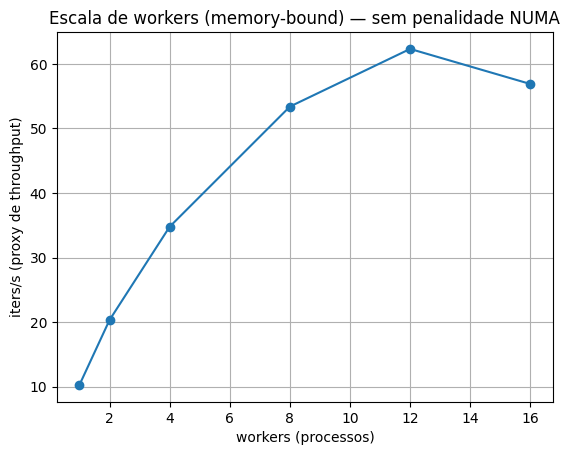

In [6]:

# 📈 Plot — Throughput vs workers

import matplotlib.pyplot as plt
plt.figure()
plt.plot(df1["workers"], df1["iters_per_s"], marker="o")
plt.xlabel("workers (processos)")
plt.ylabel("iters/s (proxy de throughput)")
plt.title("Escala de workers (memory-bound) — sem penalidade NUMA")
plt.grid(True)
plt.show()


In [7]:

# 🧪 Experimento 2 — "Memória remota" simulada (penalidade)

penalty = 2_000_000  # ns/MB (ajuste)

df_local  = sweep_workers(buf_mb=256, seconds=2.0, data_owner="A", penalty_ns_per_mb=0, migrate=False)
df_remote = sweep_workers(buf_mb=256, seconds=2.0, data_owner="A", penalty_ns_per_mb=penalty, migrate=False)

df_local["scenario"]  = "local"
df_remote["scenario"] = "remoto (penalidade)"
df2 = pd.concat([df_local, df_remote], ignore_index=True)
df2


,workers,buf_mb,seconds,iters_total,iters_per_s,data_owner,penalty_ns_per_mb,migrate,scenario
0,1,256,2.092147,22,10.515512,A,0,False,local
1,2,256,2.135325,46,21.542386,A,0,False,local
2,4,256,2.211881,79,35.716205,A,0,False,local
3,8,256,2.321743,125,53.838873,A,0,False,local
4,12,256,2.437287,145,59.492381,A,0,False,local
5,16,256,2.578306,166,64.383358,A,0,False,local
6,1,256,2.049780,22,10.732860,A,2000000,False,remoto (penalidade)
7,2,256,2.512638,25,9.949703,A,2000000,False,remoto (penalidade)
8,4,256,2.601446,50,19.220076,A,2000000,False,remoto (penalidade)
9,8,256,2.742321,92,33.548223,A,2000000,False,remoto (penalidade)


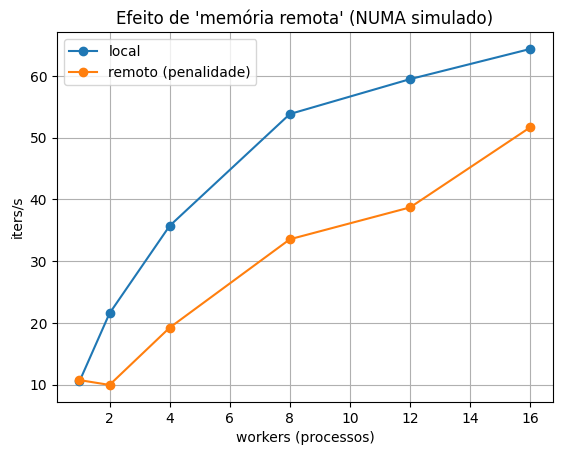

In [8]:

# 📈 Plot — Local vs Remoto

plt.figure()
for label, g in df2.groupby("scenario"):
    plt.plot(g["workers"], g["iters_per_s"], marker="o", label=label)
plt.xlabel("workers (processos)")
plt.ylabel("iters/s")
plt.title("Efeito de 'memória remota' (NUMA simulado)")
plt.grid(True)
plt.legend()
plt.show()


In [9]:

# 🧪 Experimento 3 — Migração vs fixo

penalty = 1_000_000  # ns/MB (ajuste)

df_fix  = sweep_workers(buf_mb=256, seconds=2.0, data_owner="A", penalty_ns_per_mb=penalty, migrate=False)
df_mig  = sweep_workers(buf_mb=256, seconds=2.0, data_owner="A", penalty_ns_per_mb=penalty, migrate=True)

df_fix["scenario"] = "fixo"
df_mig["scenario"] = "migração"
df3 = pd.concat([df_fix, df_mig], ignore_index=True)
df3


,workers,buf_mb,seconds,iters_total,iters_per_s,data_owner,penalty_ns_per_mb,migrate,scenario
0,1,256,2.164282,23,10.627081,A,1000000,False,fixo
1,2,256,2.272645,30,13.200480,A,1000000,False,fixo
2,4,256,2.278313,55,24.140670,A,1000000,False,fixo
3,8,256,2.478814,96,38.728200,A,1000000,False,fixo
4,12,256,2.471000,125,50.586815,A,1000000,False,fixo
5,16,256,2.717594,150,55.195878,A,1000000,False,fixo
6,1,256,2.204521,14,6.350587,A,1000000,True,migração
7,2,256,2.260170,29,12.830895,A,1000000,True,migração
8,4,256,2.339229,56,23.939510,A,1000000,True,migração
9,8,256,2.687407,96,35.722161,A,1000000,True,migração


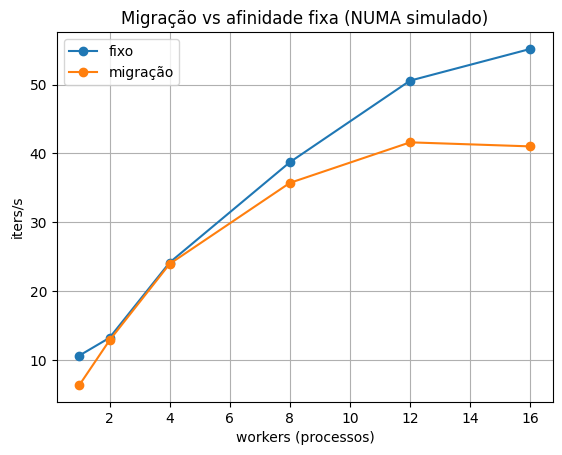

In [10]:

# 📈 Plot — Migração

import matplotlib.pyplot as plt
plt.figure()
for label, g in df3.groupby("scenario"):
    plt.plot(g["workers"], g["iters_per_s"], marker="o", label=label)
plt.xlabel("workers (processos)")
plt.ylabel("iters/s")
plt.title("Migração vs afinidade fixa (NUMA simulado)")
plt.grid(True)
plt.legend()
plt.show()


# ✅ Tarefa em grupo (12–15 min)

Liste **3 hipóteses** para a piora em 32 threads (vs 16). Para cada uma:
1) mecanismo no hardware
2) sintoma em métricas
3) teste simples (taskset/afinidade, variar workers, variar penalidade, etc.)

**Dica**: use os resultados dos Experimentos 1–3 para escolher as hipóteses mais prováveis.
